### Perform Clustering

In [1]:
# Imports
import numpy as np
import os, sys
import matplotlib.pyplot as plt

if "__file__" in globals():
    script_dir = os.path.dirname(os.path.abspath(__file__))
else:
    script_dir = os.getcwd()

utils_dir = os.path.abspath(os.path.join(script_dir, "..", "..", "..", "Utils"))
output_dir = os.path.abspath(os.path.join(script_dir, "..", "Outputs"))

sys.path.append(utils_dir)
from clustering import Cluster
from yaml_processor import load_config, save_config
from data_processing import load_dataset, save_dataset, save_cluster, parameter_plot
from sensor_processing import sensor_processing

config_file = os.path.abspath(os.path.join(script_dir, "..", "configuration.yaml"))
config_global = load_config(config_file)

##### Initialization

In [2]:
# Minimum number of data points in each cluster
min_data_per_cluster = 16
normalize = True

In [3]:
dataset_path = os.path.join(output_dir, "datasets")
FS_train, param_train, ft_train, disp_norm, vel_norm, ft_norm = load_dataset(os.path.join(dataset_path, "Train"), normalize=normalize)
FS_val, param_val, ft_val, _, _, _ = load_dataset(os.path.join(dataset_path, "Val"), normalize, disp_norm, vel_norm, ft_norm)
FS_test, param_test, ft_test, _, _, _ = load_dataset(os.path.join(dataset_path, "Test"), normalize, disp_norm, vel_norm, ft_norm)

In [5]:
# Apply Sensor Placement
sp = sensor_processing(FS_train[:, 1], config_global)
A_Mat, C_Mat, pinv_Theta, sensor_placement = sp.load(output_dir)
RS_train, RS_val, RS_test = sp.apply_sensors(FS_train, FS_val, FS_test)

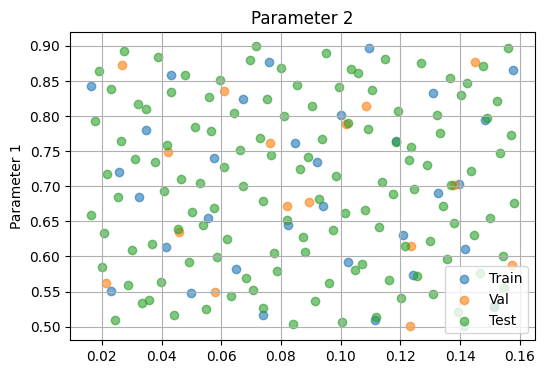

In [6]:
parameter_plot(param_train, param_val, param_test)

Perform Clustering

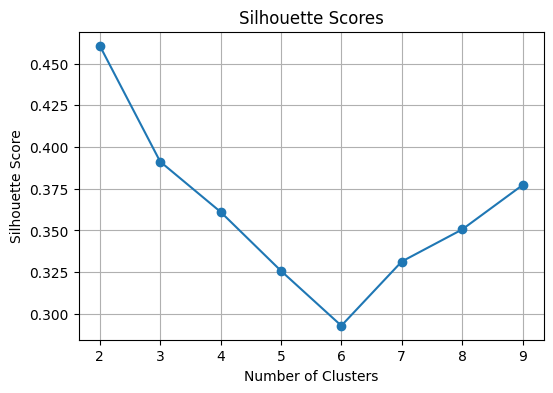

k=2, silhouette=0.461
k=3, silhouette=0.391
k=4, silhouette=0.361
k=5, silhouette=0.326
k=6, silhouette=0.293
k=7, silhouette=0.331
k=8, silhouette=0.351
k=9, silhouette=0.377


In [7]:
clust = Cluster(RS_train[:, 1], param_train) # clustering using velocity data
sil_scores = clust.find_best_k_by_silhouette(k_range=range(2, 10))

Choose optimal number of clusters

In [8]:
n_clusters = 1

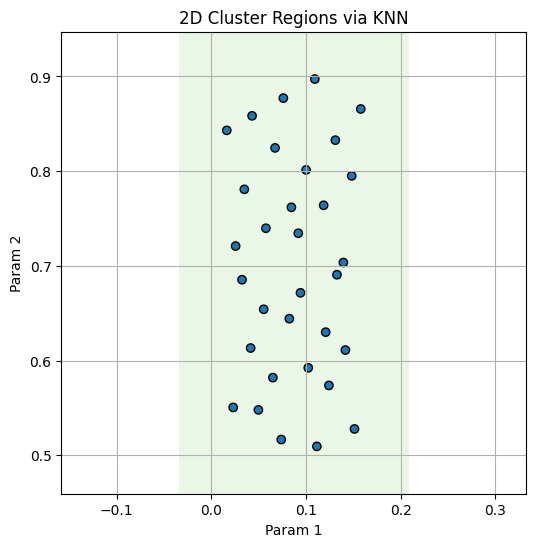

In [9]:
clust.find_clusters(n_clusters=n_clusters)
clust.plot_decision_regions()

In [14]:
for cluster in range(n_clusters):
    save_cluster(os.path.join(output_dir, "datasets", "Train"), cluster, FS_train, param_train, ft_train, disp_norm, vel_norm, ft_norm)
    save_cluster(os.path.join(output_dir, "datasets", "Val"), cluster, FS_val, param_val, ft_val, disp_norm, vel_norm, ft_norm)
    save_cluster(os.path.join(output_dir, "datasets", "Test"), cluster, FS_test, param_test, ft_test, disp_norm, vel_norm, ft_norm)

In [15]:
config_global["data"]["n_clusters"] = n_clusters
save_config(config_file, config_global)